## Problem Statement

This tutorial takes a practical and coding-focused approach. We'll learn how to use _decision trees_ and _random forests_ to solve a real-world problem from [Kaggle](https://kaggle.com/datasets):

> **QUESTION**: The [Rain in Australia dataset](https://kaggle.com/jsphyg/weather-dataset-rattle-package) contains about 10 years of daily weather observations from numerous Australian weather stations. Here's a small sample from the dataset:
>
> ![](https://i.imgur.com/5QNJvir.png)
>
> As a data scientist at the Bureau of Meteorology, you are tasked with creating a fully-automated system that can use today's weather data for a given location to predict whether it will rain at the location tomorrow.
>
>
> ![](https://i.imgur.com/KWfcpcO.png)

In [2]:
pip install opendatasets --upgrade --quiet

In [3]:
import opendatasets as od
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1500)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

## Downloading the Data

The dataset is available at https://www.kaggle.com/jsphyg/weather-dataset-rattle-package .



In [4]:
od.download('https://www.kaggle.com/jsphyg/weather-dataset-rattle-package')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: q
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package


100%|██████████| 3.83M/3.83M [00:00<00:00, 216MB/s]

In [5]:
os.listdir('weather-dataset-rattle-package')

['weatherAUS.csv']

In [6]:
raw_df = pd.read_csv('/content/weather-dataset-rattle-package/weatherAUS.csv')

In [7]:
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,9.0,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,13.0,7.0,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [8]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [9]:
raw_df.isna().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566




Let's drop any rows where the value of the target column `RainTomorrow` in empty.

In [10]:
raw_df.dropna(subset=['RainTomorrow'], inplace=True)

## Preparing the Data for Training

We'll perform the following steps to prepare the dataset for training:

1. Create a train/test/validation split
2. Identify input and target columns
3. Identify numeric and categorical columns
4. Impute (fill) missing numeric values
5. Scale numeric values to the $(0, 1)$ range
6. Encode categorical columns to one-hot vectors

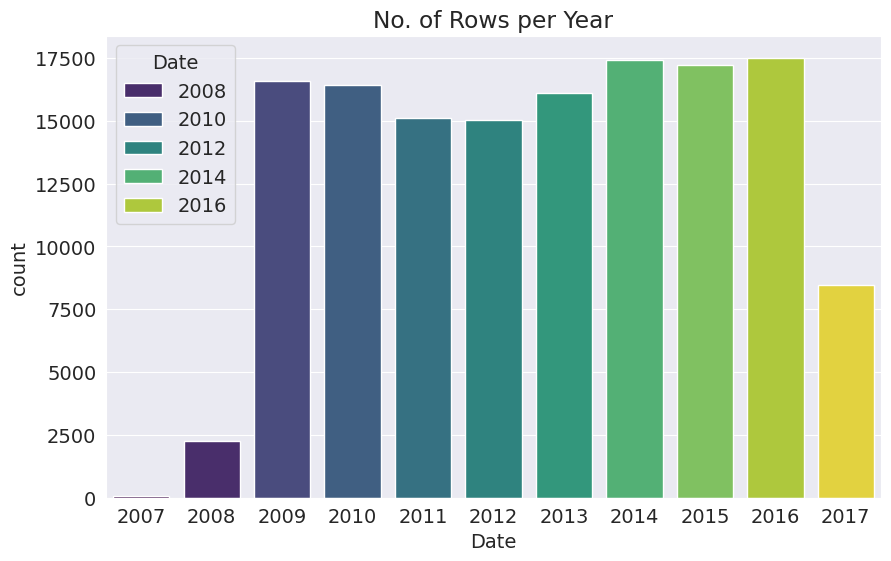

In [11]:
plt.title('No. of Rows per Year')
sns.countplot(x=pd.to_datetime(raw_df.Date).dt.year, hue=pd.to_datetime(raw_df.Date).dt.year, palette='viridis' ); # .dt.year extracts the year from the datetime object

While working with chronological data, it's often a good idea to separate the training, validation and test sets with time, so that the model is trained on data from the past and evaluated on data from the future.

We'll use the data till 2014 for the training set, data from 2015 for the validation set, and the data from 2016 & 2017 for the test set.  

In [12]:
year = pd.to_datetime(raw_df.Date).dt.year

train_df = raw_df[year < 2015]
val_df = raw_df[year == 2015]
test_df = raw_df[year > 2015]
print("Train Data:",train_df)
print("Validation Data:",val_df)
print("Test Data:",test_df)

Train Data:               Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-12-01   Albury     13.4     22.9       0.6          NaN   
1       2008-12-02   Albury      7.4     25.1       0.0          NaN   
2       2008-12-03   Albury     12.9     25.7       0.0          NaN   
3       2008-12-04   Albury      9.2     28.0       0.0          NaN   
4       2008-12-05   Albury     17.5     32.3       1.0          NaN   
...            ...      ...      ...      ...       ...          ...   
144548  2014-12-27    Uluru     16.9     33.2       0.0          NaN   
144549  2014-12-28    Uluru     15.1     36.8       0.0          NaN   
144550  2014-12-29    Uluru     17.3     37.8       0.0          NaN   
144551  2014-12-30    Uluru     20.1     38.5       0.0          NaN   
144552  2014-12-31    Uluru     22.5     39.6       0.0          NaN   

        Sunshine WindGustDir  WindGustSpeed WindDir9am WindDir3pm  \
0            NaN           W           44.0          W

### Input and Target Columns

Let's identify the input and target columns.

In [13]:
input_cols = list(train_df.columns)[1:-1]
target_col = 'RainTomorrow'

In [14]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [15]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [16]:
test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

### Identifying Numerical and Categorical Data

In [17]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()
print("="*35)
print("Numerical Columns:\n")
for i in numeric_cols:
  print(i)


Numerical Columns:

MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustSpeed
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm


In [18]:
print("="*35,"\n")
print("Categorical Columns:\n")
for j in categorical_cols:
  print(j)



Categorical Columns:

Location
WindGustDir
WindDir9am
WindDir3pm
RainToday


### Imputing missing numeric values

Correlation with RainTomorrow:
 RainTomorrow     1.000000
Humidity3pm      0.449367
Cloud3pm         0.392662
Cloud9am         0.328498
RainToday        0.318166
Humidity9am      0.260722
Rainfall         0.244533
WindGustSpeed    0.231589
WindSpeed9am     0.092783
MinTemp          0.085724
WindSpeed3pm     0.084467
Temp9am         -0.027409
Evaporation     -0.126095
MaxTemp         -0.164452
Temp3pm         -0.196708
Pressure3pm     -0.224782
Pressure9am     -0.246940
Sunshine        -0.454338
dtype: float64


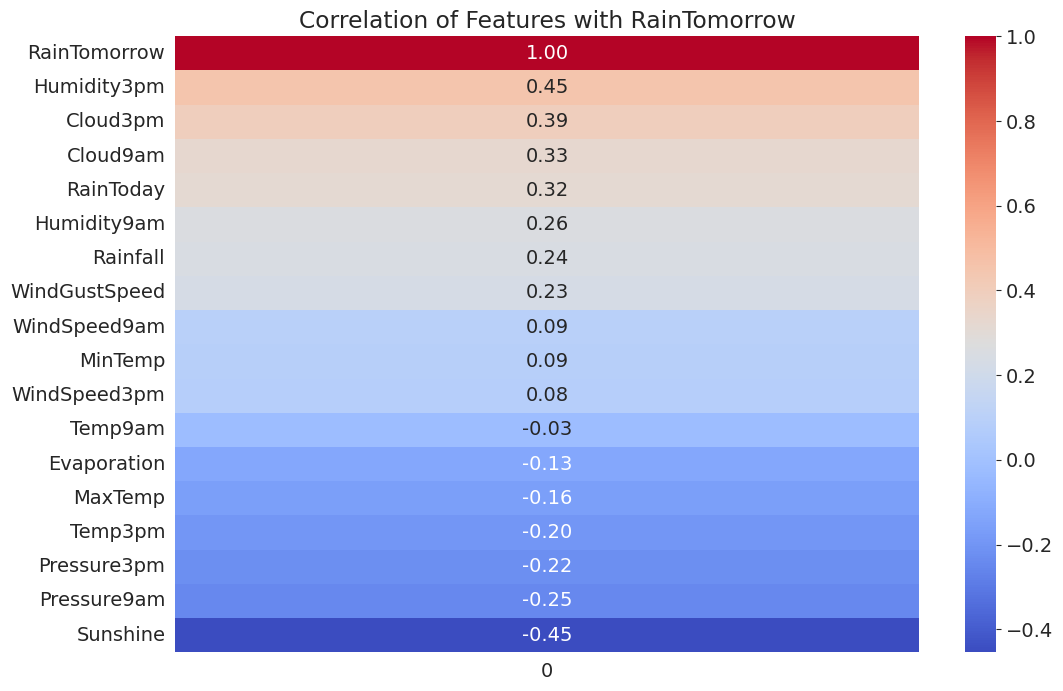


Selected features based on absolute correlation > 0.1:
['Humidity3pm', 'Cloud3pm', 'Cloud9am', 'RainToday', 'Humidity9am', 'Rainfall', 'WindGustSpeed', 'Evaporation', 'MaxTemp', 'Temp3pm', 'Pressure3pm', 'Pressure9am', 'Sunshine']

Suggested final input columns for modeling: ['Humidity3pm', 'Rainfall', 'Humidity9am', 'Cloud3pm', 'Cloud9am', 'Temp3pm', 'MinTemp', 'WindGustSpeed', 'Temp9am', 'MaxTemp', 'Pressure9am', 'Pressure3pm', 'WindSpeed3pm', 'WindSpeed9am', 'RainToday']


In [19]:
# Map 'No' to 0 and 'Yes' to 1 for the target variable
train_targets_encoded = train_targets.map({'No': 0, 'Yes': 1})
val_targets_encoded = val_targets.map({'No': 0, 'Yes': 1})
test_targets_encoded = test_targets.map({'No': 0, 'Yes': 1})

# Map 'No' to 0 and 'Yes' to 1 for 'RainToday' in input dataframes
train_inputs_corr = train_inputs.copy()
val_inputs_corr = val_inputs.copy()
test_inputs_corr = test_inputs.copy()

train_inputs_corr['RainToday'] = train_inputs_corr['RainToday'].map({'No': 0, 'Yes': 1})
val_inputs_corr['RainToday'] = val_inputs_corr['RainToday'].map({'No': 0, 'Yes': 1})
test_inputs_corr['RainToday'] = test_inputs_corr['RainToday'].map({'No': 0, 'Yes': 1})

# Combine train_inputs with encoded train_targets for correlation calculation
combined_df = pd.concat([train_inputs_corr[numeric_cols + ['RainToday']], train_targets_encoded], axis=1)

# Calculate correlations with the target variable
correlations = combined_df.corrwith(combined_df['RainTomorrow']).sort_values(ascending=False)

print("Correlation with RainTomorrow:\n", correlations)

# Visualize correlations with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation of Features with RainTomorrow')
plt.show()

# Now, let's consider how to select a subset of columns based on these correlations.
# You can choose a threshold for correlation (e.g., absolute correlation > 0.1)
# or select the top N features. You might also want to consider domain knowledge.

# Example: Selecting features with an absolute correlation above a certain threshold
correlation_threshold = 0.1
selected_features = correlations[abs(correlations) > correlation_threshold].index.tolist()

# Remove 'RainTomorrow' itself from the selected features list if it's included
if 'RainTomorrow' in selected_features:
    selected_features.remove('RainTomorrow')

print(f"\nSelected features based on absolute correlation > {correlation_threshold}:\n{selected_features}")

# For simplicity in this exercise, let's update input_cols to include only numerical and 'RainToday' for now
# For other categorical columns, further encoding would be needed before correlation.
# For the purpose of this exercise, you might choose to remove features with very low correlation,
# or just focus on the highly correlated ones. Let's make an example selection.

# Example of manually selected input columns based on observation
# In a real scenario, you would evaluate models with different subsets.

# This is a suggested approach to select a subset.
# You can modify `final_input_cols_for_model` based on the heatmap and your analysis.
final_input_cols_for_model = ['Humidity3pm', 'Rainfall', 'Humidity9am', 'Cloud3pm', 'Cloud9am',
                              'Temp3pm', 'MinTemp', 'WindGustSpeed', 'Temp9am', 'MaxTemp',
                              'Pressure9am', 'Pressure3pm', 'WindSpeed3pm', 'WindSpeed9am', 'RainToday']

print(f"\nSuggested final input columns for modeling: {final_input_cols_for_model}")

# You would then re-assign your input dataframes using this new list
# train_inputs = train_df[final_input_cols_for_model].copy()
# val_inputs = val_df[final_input_cols_for_model].copy()
# test_inputs = test_df[final_input_cols_for_model].copy()

# And redefine numeric_cols and categorical_cols based on this new subset
# numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
# categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

Skewness of numerical features in train_inputs:
 Rainfall         10.023560
Evaporation       3.128198
WindGustSpeed     0.877898
WindSpeed9am      0.762061
WindSpeed3pm      0.612034
Temp3pm           0.272212
MaxTemp           0.246096
Temp9am           0.102963
MinTemp           0.029302
Humidity3pm       0.019792
Pressure3pm      -0.065145
Pressure9am      -0.115032
Cloud9am         -0.174353
Cloud3pm         -0.205229
Humidity9am      -0.484061
Sunshine         -0.496206
dtype: float64


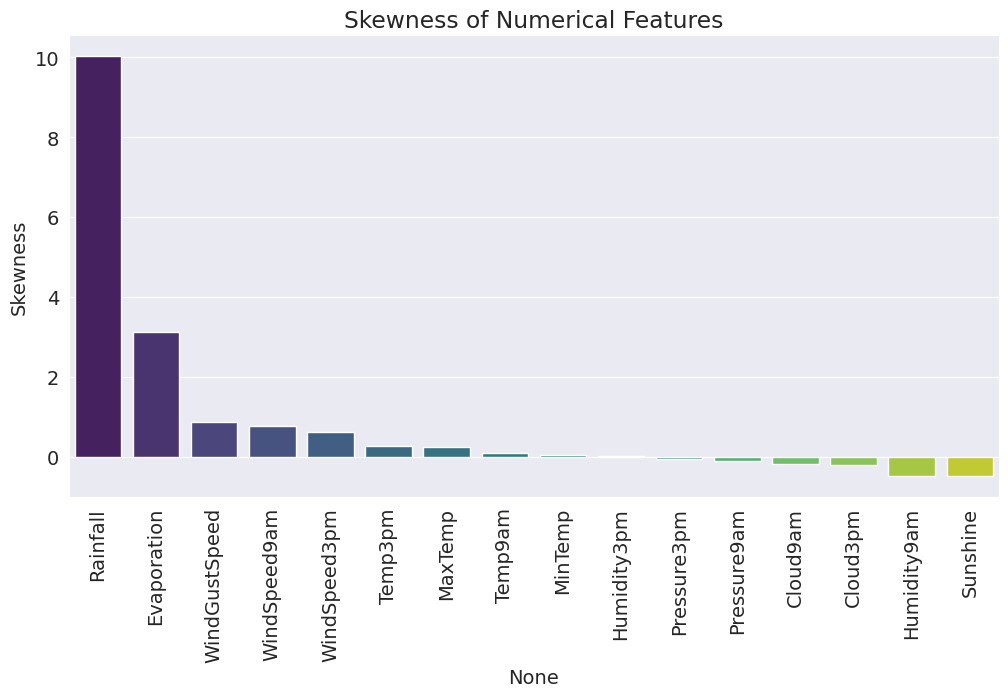


Interpretation of Skewness:

  - A skewness value close to 0 indicates a symmetrical distribution (like a normal distribution).
  - Positive skewness (values > 0) means the tail of the distribution is longer on the right side, with the mean > median.
  - Negative skewness (values < 0) means the tail of the distribution is longer on the left side, with the mean < median.

Based on these skewness values:

  - For features with low skewness (e.g., between -0.5 and 0.5), imputation with the mean might be appropriate.
  - For highly skewed features (e.g., absolute skewness > 1 or 2), imputation with the median is generally preferred 
    because the median is less sensitive to extreme values that cause the skew.
  - Examples of highly skewed features here include Rainfall, Sunshine, and Evaporation. 
    For these, a median imputation strategy might be more suitable than mean.


In [20]:
skewness = train_inputs[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numerical features in train_inputs:\n", skewness)

# Visualize skewness
plt.figure(figsize=(12, 6))
sns.barplot(x=skewness.index, y=skewness.values, hue=skewness.index, palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Skewness of Numerical Features')
plt.ylabel('Skewness')
plt.show()

print("\nInterpretation of Skewness:\n")
print("  - A skewness value close to 0 indicates a symmetrical distribution (like a normal distribution).")
print("  - Positive skewness (values > 0) means the tail of the distribution is longer on the right side, with the mean > median.")
print("  - Negative skewness (values < 0) means the tail of the distribution is longer on the left side, with the mean < median.")
print("\nBased on these skewness values:\n")
print("  - For features with low skewness (e.g., between -0.5 and 0.5), imputation with the mean might be appropriate.")
print("  - For highly skewed features (e.g., absolute skewness > 1 or 2), imputation with the median is generally preferred ")
print("    because the median is less sensitive to extreme values that cause the skew.")
print("  - Examples of highly skewed features here include Rainfall, Sunshine, and Evaporation. ")
print("    For these, a median imputation strategy might be more suitable than mean.")

In [21]:
imputer = SimpleImputer(strategy = 'median').fit(raw_df[numeric_cols])

In [22]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

Skewness of numerical features in train_inputs:
 Rainfall         10.071002
Evaporation       4.096559
WindGustSpeed     0.928843
WindSpeed9am      0.770473
WindSpeed3pm      0.614683
Temp3pm           0.274372
MaxTemp           0.246685
Temp9am           0.103846
MinTemp           0.029370
Humidity3pm       0.019043
Pressure3pm      -0.071046
Pressure9am      -0.124325
Humidity9am      -0.489870
Cloud9am         -0.526978
Cloud3pm         -0.548563
Sunshine         -0.991732
dtype: float64
0.9001477353144569


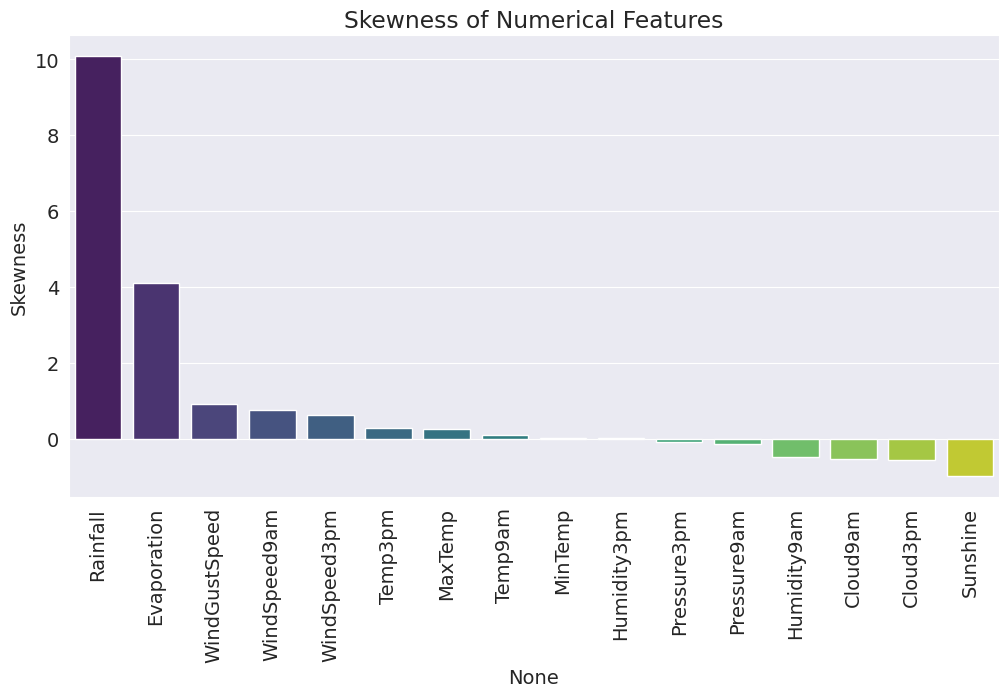

In [23]:
# After imputing
skewness = train_inputs[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numerical features in train_inputs:\n", skewness)
print(skewness.mean())
# Visualize skewness
plt.figure(figsize=(12, 6))
sns.barplot(x=skewness.index, y=skewness.values, hue=skewness.index, palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.title('Skewness of Numerical Features')
plt.ylabel('Skewness')
plt.show()

### Scaling Numeric Features

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(raw_df[numeric_cols])

In [25]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [26]:
# Check if the numerical features in val_inputs have been scaled to the (0,1) range
# by displaying their minimum and maximum values.
val_inputs.describe().loc[['min', 'max']]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
min,0.007075,0.030246,0.000000,0.000000,0.0,0.007752,0.000000,0.000000,0.04,0.0,0.125620,0.0816,0.000000,0.000000,0.021097,0.026871
max,0.952830,0.948960,0.666307,0.485517,1.0,1.000000,0.669231,0.850575,1.00,1.0,0.971901,0.9632,0.888889,0.888889,0.943038,0.925144


### Encoding Categorical Data

In [27]:
from sklearn.preprocessing import OneHotEncoder

In [28]:
encoder = OneHotEncoder(handle_unknown='ignore').fit(raw_df[categorical_cols])

In [29]:
# get_feature_names() is an outdated method for OneHotEncoder
# encoded_cols = list(encoder.get_feature_names(categorical_cols))

In [30]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [31]:
encoded_cols

['Location_Adelaide',
 'Location_Albany',
 'Location_Albury',
 'Location_AliceSprings',
 'Location_BadgerysCreek',
 'Location_Ballarat',
 'Location_Bendigo',
 'Location_Brisbane',
 'Location_Cairns',
 'Location_Canberra',
 'Location_Cobar',
 'Location_CoffsHarbour',
 'Location_Dartmoor',
 'Location_Darwin',
 'Location_GoldCoast',
 'Location_Hobart',
 'Location_Katherine',
 'Location_Launceston',
 'Location_Melbourne',
 'Location_MelbourneAirport',
 'Location_Mildura',
 'Location_Moree',
 'Location_MountGambier',
 'Location_MountGinini',
 'Location_Newcastle',
 'Location_Nhil',
 'Location_NorahHead',
 'Location_NorfolkIsland',
 'Location_Nuriootpa',
 'Location_PearceRAAF',
 'Location_Penrith',
 'Location_Perth',
 'Location_PerthAirport',
 'Location_Portland',
 'Location_Richmond',
 'Location_Sale',
 'Location_SalmonGums',
 'Location_Sydney',
 'Location_SydneyAirport',
 'Location_Townsville',
 'Location_Tuggeranong',
 'Location_Uluru',
 'Location_WaggaWagga',
 'Location_Walpole',
 'Locat

In [32]:
train_df[categorical_cols].fillna('0')
val_df[categorical_cols].fillna('0')
test_df[categorical_cols].fillna('0')

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
2498,Albury,ENE,0,ESE,No
2499,Albury,SSE,SSE,SE,No
2500,Albury,ENE,ESE,ENE,Yes
2501,Albury,SSE,SE,SSE,Yes
2502,Albury,ENE,SE,SSE,Yes
...,...,...,...,...,...
145454,Uluru,E,ESE,E,No
145455,Uluru,E,SE,ENE,No
145456,Uluru,NNW,SE,N,No
145457,Uluru,N,SE,WNW,No


In [33]:
train_inputs_encoded_array = encoder.transform(train_inputs[categorical_cols]).toarray()
val_inputs_encoded_array = encoder.transform(val_inputs[categorical_cols]).toarray()
test_inputs_encoded_array = encoder.transform(test_inputs[categorical_cols]).toarray()

# Create DataFrames from the encoded arrays, preserving original indices
train_inputs_encoded_df = pd.DataFrame(train_inputs_encoded_array, columns=encoded_cols, index=train_inputs.index)
val_inputs_encoded_df = pd.DataFrame(val_inputs_encoded_array, columns=encoded_cols, index=val_inputs.index)
test_inputs_encoded_df = pd.DataFrame(test_inputs_encoded_array, columns=encoded_cols, index=test_inputs.index)

# Drop original categorical columns and concatenate with new encoded columns
train_inputs = pd.concat([train_inputs.drop(columns=categorical_cols), train_inputs_encoded_df], axis=1)
val_inputs = pd.concat([val_inputs.drop(columns=categorical_cols), val_inputs_encoded_df], axis=1)
test_inputs = pd.concat([test_inputs.drop(columns=categorical_cols), test_inputs_encoded_df], axis=1)

print("Categorical features successfully one-hot encoded and original columns dropped.")
print("Shape of transformed train_inputs:", train_inputs.shape)
print(train_inputs.head())

Categorical features successfully one-hot encoded and original columns dropped.
Shape of transformed train_inputs: (98988, 119)
    MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  WindGustSpeed  \
0  0.516509  0.523629  0.001617     0.033103  0.586207       0.294574   
1  0.375000  0.565217  0.000000     0.033103  0.586207       0.294574   
2  0.504717  0.576560  0.000000     0.033103  0.586207       0.310078   
3  0.417453  0.620038  0.000000     0.033103  0.586207       0.139535   
4  0.613208  0.701323  0.002695     0.033103  0.586207       0.271318   

   WindSpeed9am  WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  \
0      0.153846      0.275862         0.71         0.22     0.449587   
1      0.030769      0.252874         0.44         0.25     0.497521   
2      0.146154      0.298851         0.38         0.30     0.447934   
3      0.084615      0.103448         0.45         0.16     0.613223   
4      0.053846      0.229885         0.82         0.33     0.500826   



In [34]:
test_inputs

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2498,0.681604,0.801512,0.000000,0.033103,0.586207,0.372093,0.000000,0.080460,0.46,0.17,0.543802,0.5136,0.777778,0.333333,0.702532,0.808061,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,0.693396,0.725898,0.001078,0.033103,0.586207,0.341085,0.069231,0.195402,0.54,0.30,0.505785,0.5008,0.888889,0.888889,0.675105,0.712092,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,0.634434,0.527410,0.005930,0.033103,0.586207,0.325581,0.084615,0.448276,0.62,0.67,0.553719,0.6032,0.888889,0.888889,0.611814,0.477927,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2501,0.608491,0.538752,0.042049,0.033103,0.586207,0.255814,0.069231,0.195402,0.74,0.65,0.618182,0.6304,0.888889,0.888889,0.556962,0.518234,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

As a final step, let's drop the textual categorical columns, so that we're left with just numeric data.

In [35]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [36]:
X_test

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Location_Adelaide,Location_Albany,Location_Albury,Location_AliceSprings,Location_BadgerysCreek,Location_Ballarat,Location_Bendigo,Location_Brisbane,Location_Cairns,Location_Canberra,Location_Cobar,Location_CoffsHarbour,Location_Dartmoor,Location_Darwin,Location_GoldCoast,Location_Hobart,Location_Katherine,Location_Launceston,Location_Melbourne,Location_MelbourneAirport,Location_Mildura,Location_Moree,Location_MountGambier,Location_MountGinini,Location_Newcastle,Location_Nhil,Location_NorahHead,Location_NorfolkIsland,Location_Nuriootpa,Location_PearceRAAF,Location_Penrith,Location_Perth,Location_PerthAirport,Location_Portland,Location_Richmond,Location_Sale,Location_SalmonGums,Location_Sydney,Location_SydneyAirport,Location_Townsville,Location_Tuggeranong,Location_Uluru,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,WindGustDir_E,WindGustDir_ENE,WindGustDir_ESE,WindGustDir_N,WindGustDir_NE,WindGustDir_NNE,WindGustDir_NNW,WindGustDir_NW,WindGustDir_S,WindGustDir_SE,WindGustDir_SSE,WindGustDir_SSW,WindGustDir_SW,WindGustDir_W,WindGustDir_WNW,WindGustDir_WSW,WindGustDir_nan,WindDir9am_E,WindDir9am_ENE,WindDir9am_ESE,WindDir9am_N,WindDir9am_NE,WindDir9am_NNE,WindDir9am_NNW,WindDir9am_NW,WindDir9am_S,WindDir9am_SE,WindDir9am_SSE,WindDir9am_SSW,WindDir9am_SW,WindDir9am_W,WindDir9am_WNW,WindDir9am_WSW,WindDir9am_nan,WindDir3pm_E,WindDir3pm_ENE,WindDir3pm_ESE,WindDir3pm_N,WindDir3pm_NE,WindDir3pm_NNE,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2498,0.681604,0.801512,0.000000,0.033103,0.586207,0.372093,0.000000,0.080460,0.46,0.17,0.543802,0.5136,0.777778,0.333333,0.702532,0.808061,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,0.693396,0.725898,0.001078,0.033103,0.586207,0.341085,0.069231,0.195402,0.54,0.30,0.505785,0.5008,0.888889,0.888889,0.675105,0.712092,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,0.634434,0.527410,0.005930,0.033103,0.586207,0.325581,0.084615,0.448276,0.62,0.67,0.553719,0.6032,0.888889,0.888889,0.611814,0.477927,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2501,0.608491,0.538752,0.042049,0.033103,0.586207,0.255814,0.069231,0.195402,0.74,0.65,0.618182,0.6304,0.888889,0.888889,0.556962,0.518234,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

## Training and Visualizing Decision Trees

A decision tree in general parlance represents a hierarchical series of binary decisions:

<img src="https://i.imgur.com/qSH4lqz.png" width="480">

A decision tree in machine learning works in exactly the same way, and except that we let the computer figure out the optimal structure & hierarchy of decisions, instead of coming up with criteria manually.

### Training

We can use `DecisionTreeClassifier` from `sklearn.tree` to train a decision tree.

In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
model = DecisionTreeClassifier(random_state=42)

In [39]:
%%time
model.fit(X_train, train_targets)

CPU times: user 4.25 s, sys: 49.4 ms, total: 4.3 s
Wall time: 4.38 s


DecisionTreeClassifier(random_state=42)

### Evaluation

Let's evaluate the decision tree using the accuracy score.

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [41]:
train_preds = model.predict(X_train)

In [42]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [43]:
pd.value_counts(train_preds)

/tmp/ipykernel_366/1258350197.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_preds)


,count
No,76707
Yes,22281


In [44]:
train_probs = model.predict_proba(X_train)

In [45]:
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

Seems like the decision tree is quite confident about its predictions.

Let's check the accuracy of its predictions.

In [46]:
accuracy_score(train_targets, train_preds)

0.9999797955307714

The training set accuracy is close to 100%! But we can't rely solely on the training set accuracy, we must evaluate the model on the validation set too.

We can make predictions and compute accuracy in one step using `model.score`

In [47]:
model.score(X_val, val_targets)

0.7952527421507748

Although the training accuracy is 100%, the accuracy on the validation set is just about 79%, which is only marginally better then always predicting "No".

In [48]:
val_targets.value_counts() / len(val_targets)

,count
RainTomorrow,
No,0.788289
Yes,0.211711


It appears that the model has learned the training examples perfect, and doesn't generalize well to previously unseen examples. This phenomenon is called "overfitting", and reducing overfitting is one of the most important parts of any machine learning project.

### Visualization

We can visualize the decision tree _learned_ from the training data.

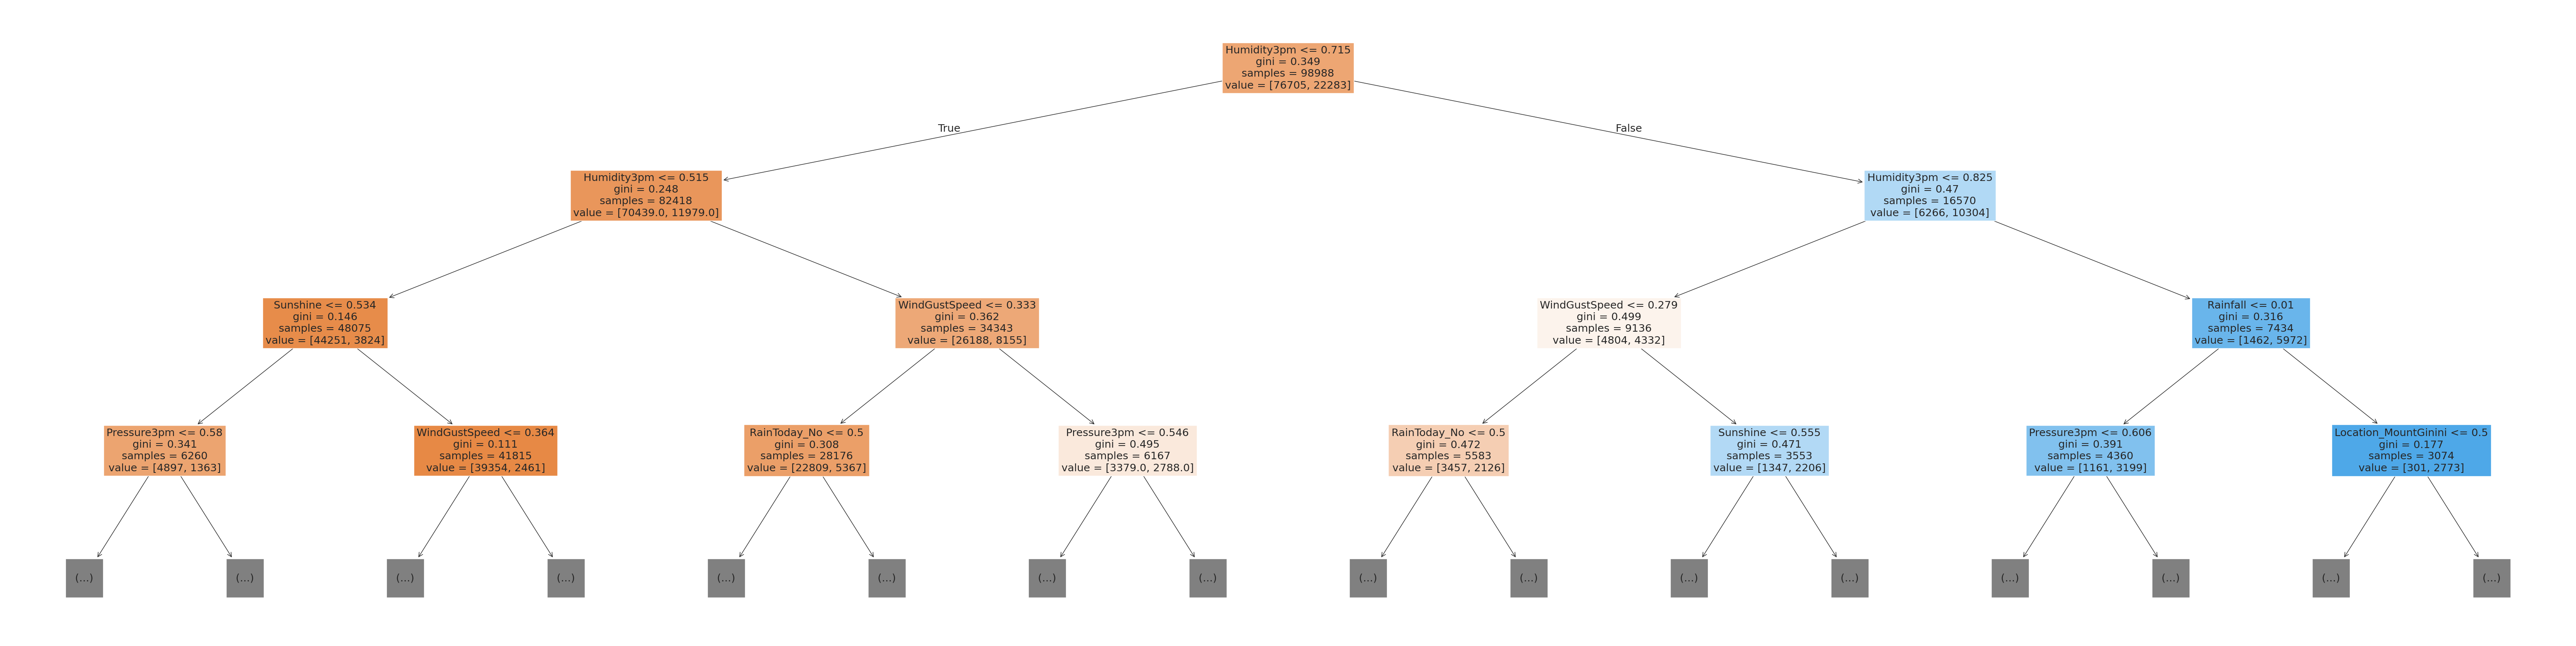

In [49]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=3, filled=True);


**How a Decision Tree is Created**

Note the `gini` value in each box. This is the loss function used by the decision tree to decide which column should be used for splitting the data, and at what point the column should be split. A lower Gini index indicates a better split. A perfect split (only one class on each side) has a Gini index of 0.

### Gini Impurity Formula:

<img src="https://i.imgur.com/CSC0gAo.png" width="240">

Conceptually speaking, while training the models evaluates all possible splits across all possible columns and picks the best one. Then, it recursively performs an optimal split for the two portions. In practice, however, it's very inefficient to check all possible splits, so the model uses a heuristic (predefined strategy) combined with some randomization.

The iterative approach of the machine learning workflow in the case of a decision tree involves growing the tree layer-by-layer:

<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">


Let's check the depth of the tree that was created.

In [50]:
# Get the depth of the trained decision tree model
model.get_depth()

44

In [51]:
from sklearn.tree import export_text
# We can also display the tree as text, which can be easier to follow for deeper trees.
tree_text = export_text(model, max_depth=10, feature_names=list(X_train.columns))
print(tree_text[:500000])
print(len(tree_text[:500000]))

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.51
|   |   |   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure9am <= 0.47
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure9am >  0.47
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 9
|   |   |   |   |   |   |   |   |   |   |--- Cloud9am >  0.83
|   |   |   |   |   |   |   |   |   |   |   |--- 


The phenomenon observed, where the training accuracy is nearly 100% but the validation accuracy is significantly lower (around 79%), is a classic example of **overfitting**.

Here's why it happens in the context of our decision tree:

1.  **Memorization vs. Generalization**: A decision tree with a very large depth (in our case, 44 levels) has the capacity to create extremely specific rules. It essentially 'memorizes' the training data, including its noise and outliers. This leads to perfect or near-perfect performance on the data it has seen during training.
2.  **Lack of Generalization**: However, these highly specific rules do not translate well to new, unseen data (like our validation set). The patterns that worked perfectly for the training examples might not hold true for slightly different examples in the validation set. As a result, the model fails to generalize, leading to a much lower accuracy on the validation data.
3.  **Complex Model**: A deep tree signifies a very complex model. While complexity can help capture intricate relationships, excessive complexity often leads to overfitting. The model is too tailored to the peculiarities of the training data and loses its ability to find broader, underlying patterns that apply to the real world.

In essence, the model learned the training data 'too well' but failed to learn the general underlying relationships that would allow it to perform accurately on new data.

### Feature Importance

Based on the gini index computations, a decision tree assigns an "importance" value to each feature. These values can be used to interpret the results given by a decision tree.

In [52]:
model.feature_importances_

array([3.82082500e-02, 3.16459002e-02, 3.00956417e-02, 2.27947852e-02,
       4.76661657e-02, 6.39277083e-02, 2.56693731e-02, 2.64377442e-02,
       3.85255338e-02, 2.73851726e-01, 3.74019612e-02, 6.12608940e-02,
       1.20328180e-02, 1.66811768e-02, 3.34165894e-02, 3.14492738e-02,
       2.52692677e-03, 1.86268069e-03, 1.76548947e-03, 5.92005694e-04,
       1.94070185e-03, 1.21812834e-03, 1.33574037e-03, 1.79887562e-03,
       9.66927110e-04, 1.39521894e-03, 1.10897327e-03, 1.42901001e-03,
       1.70039952e-03, 3.29689254e-04, 1.10386256e-03, 1.78261306e-03,
       5.55043424e-05, 1.51820275e-03, 1.12157248e-03, 1.17059049e-03,
       7.61393572e-04, 9.34148081e-04, 1.43712915e-03, 2.21493130e-03,
       4.25604111e-04, 5.93752130e-04, 1.37863056e-03, 1.51854489e-03,
       1.64128717e-03, 1.37476145e-03, 8.03547116e-04, 1.76147920e-03,
       1.36987353e-03, 1.50534381e-03, 1.17557077e-03, 1.63532705e-03,
       1.17106782e-03, 1.43027376e-03, 1.36628970e-03, 4.28704395e-04,
      

In [53]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [54]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.273852
5,WindGustSpeed,0.063928
11,Pressure3pm,0.061261
4,Sunshine,0.047666
8,Humidity9am,0.038526
0,MinTemp,0.038208
10,Pressure9am,0.037402
14,Temp9am,0.033417
1,MaxTemp,0.031646
15,Temp3pm,0.031449


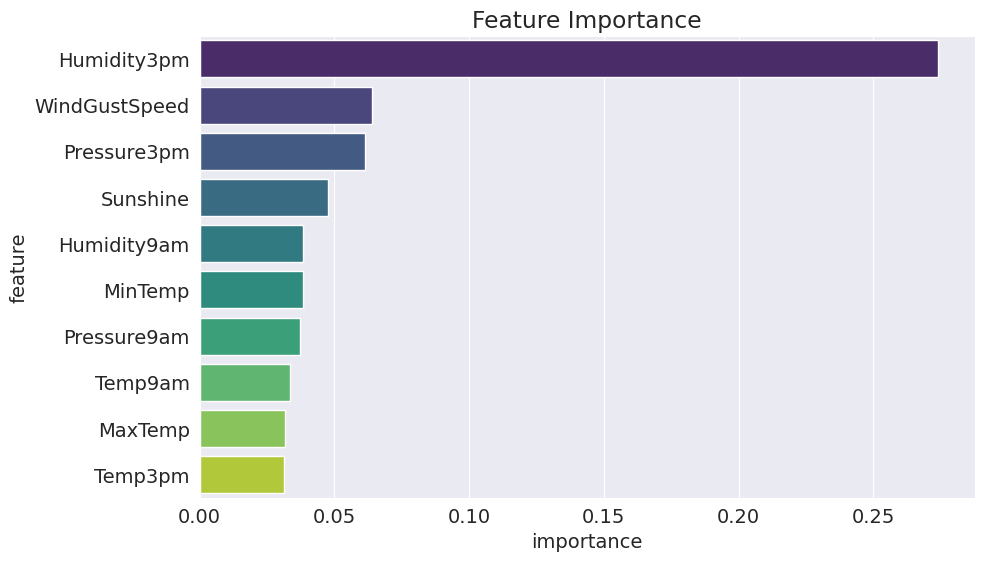

In [55]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature', hue='feature', palette='viridis', legend=False);

## Hyperparameter Tuning and Overfitting

As we saw in the previous section, our decision tree classifier memorized all training examples, leading to a 100% training accuracy, while the validation accuracy was only marginally better than a dumb baseline model. This phenomenon is called overfitting, and in this section, we'll look at some strategies for reducing overfitting.

The `DecisionTreeClassifier` accepts several arguments, some of which can be modified to reduce overfitting.

In [56]:
?DecisionTreeClassifier

### `max_depth`

By reducing the maximum depth of the decision tree, we can prevent the tree from memorizing all training examples, which may lead to better generalization

In [57]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [58]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [59]:
model.score(X_train, train_targets)

0.8291308037337859

In [60]:
model.score(X_val, val_targets)

0.8334397307178921

Great, while the training accuracy of the model has gone down, the validation accuracy of the model has increased significantly.

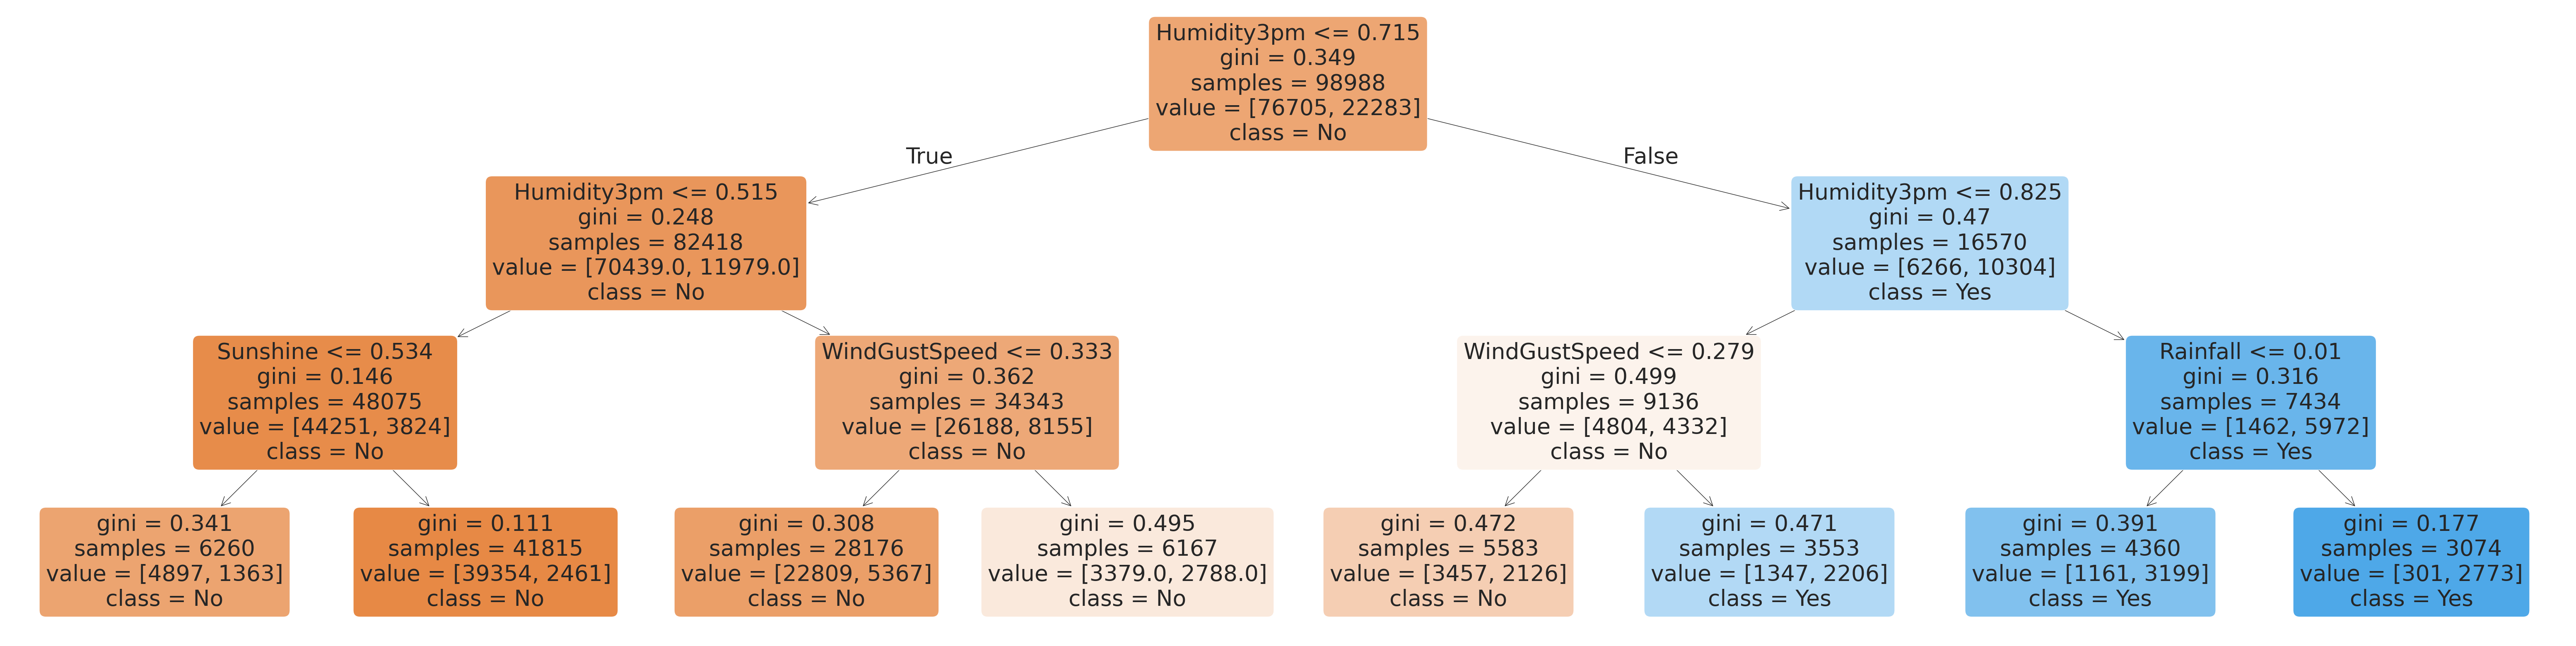

In [61]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

Let's break down the meaning of each term you see in the decision tree diagram:

*   **`gini`**: This stands for **Gini impurity**. It's a measure of the purity or impurity of a node. A node is 'pure' if all samples in it belong to the same class. A Gini impurity of 0 means the node is perfectly pure (all samples belong to one class). A higher Gini impurity indicates a more mixed distribution of classes within that node. The decision tree algorithm works by trying to find splits that minimize the Gini impurity in the resulting child nodes.

*   **`samples`**: This simply indicates the **number of training examples** that reached this particular node during the tree traversal. When a node splits, the `samples` count is divided among its child nodes based on how many examples satisfy each split condition.

*   **`value`**: This shows the **count of samples for each class** present in that node. For a binary classification problem (like 'RainTomorrow' - Yes/No), it will typically show two numbers, e.g., `[800, 200]`, meaning there are 800 samples of one class and 200 samples of the other class in this node. The order of these values corresponds to the `class_names` provided to `plot_tree`.

*   **`class`**: This represents the **majority class** within that node. It's the predicted class label for any new sample that falls into this node if it were a leaf node. The class is determined by which class has the highest count in the `value` array.

In [62]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- class: No
|   |   |--- Sunshine >  0.53
|   |   |   |--- class: No
|   |--- Humidity3pm >  0.51
|   |   |--- WindGustSpeed <= 0.33
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.33
|   |   |   |--- class: No
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- WindGustSpeed <= 0.28
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.28
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: Yes
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes



Let's experiment with different depths using a helper function.

In [63]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_acc = 1 - model.score(X_train, train_targets)
    val_acc = 1 - model.score(X_val, val_targets)
    return {'Max Depth': md, 'Training Error': train_acc, 'Validation Error': val_acc}

In [64]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: user 42.4 s, sys: 1.1 s, total: 43.5 s
Wall time: 43.8 s


In [65]:
errors_df

,Max Depth,Training Error,Validation Error
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165566,0.163484
4,5,0.159534,0.159654
5,6,0.157009,0.158203
6,7,0.153453,0.157043
7,8,0.147998,0.155650
8,9,0.141866,0.155476
9,10,0.133178,0.158784


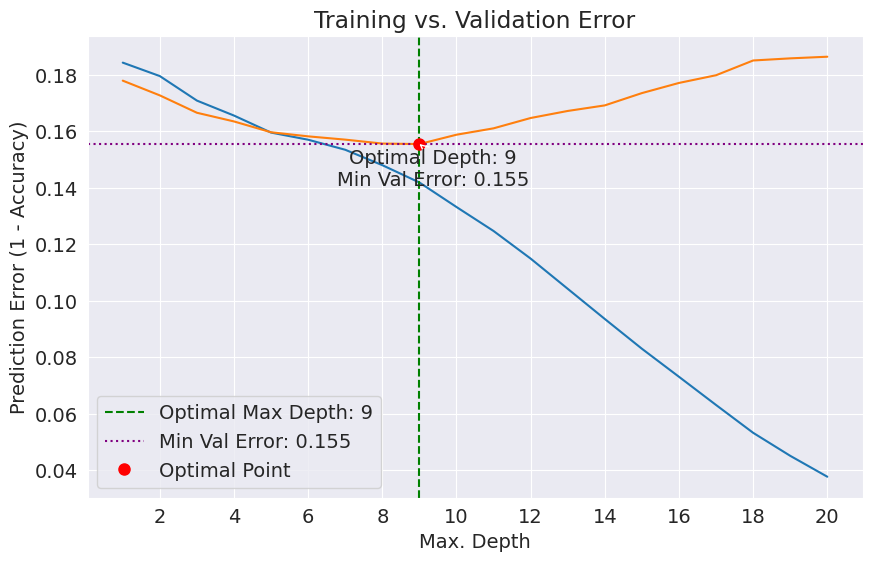

In [66]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

# Find the optimal max_depth (where Validation Error is minimum)
optimal_md_idx = errors_df['Validation Error'].idxmin()
optimal_md = errors_df.loc[optimal_md_idx, 'Max Depth']
min_val_error = errors_df.loc[optimal_md_idx, 'Validation Error']

# Plot a vertical dashed line at the optimal max_depth
plt.axvline(x=optimal_md, color='green', linestyle='--', label=f'Optimal Max Depth: {optimal_md}')

# Plot a horizontal dashed line at the minimum validation error
plt.axhline(y=min_val_error, color='purple', linestyle=':', label=f'Min Val Error: {min_val_error:.3f}')

# Plot a point at the intersection
plt.plot(optimal_md, min_val_error, 'o', color='red', markersize=8, label='Optimal Point')

# Add annotation
plt.annotate(f'Optimal Depth: {optimal_md}\nMin Val Error: {min_val_error:.3f}',
             (optimal_md, min_val_error),
             textcoords="offset points",
             xytext=(10, -30),
             ha='center',
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

plt.legend()

This is a common pattern you'll see with all machine learning algorithms:

<img src="https://i.imgur.com/EJCrSZw.png" width="480">




You'll often need to tune hyperparameters carefully to find the optimal fit. In the above case, it appears that a maximum depth of 7 results in the lowest validation error.

In [67]:
model = DecisionTreeClassifier(max_depth=8, random_state=42).fit(X_train, train_targets)
print("Train",model.score(X_train, train_targets),"\nVal",model.score(X_val, val_targets))


Train 0.8520022629005536 
Val 0.8443502988799257


In [68]:
# model = DecisionTreeClassifier(max_depth=7, random_state=42).fit(X_train, train_targets)
# print("Train",model.score(X_train, train_targets),"\nVal",
# model.score(X_val, val_targets))

### `max_leaf_nodes`

Another way to control the size of complexity of a decision tree is to limit the number of leaf nodes. This allows branches of the tree to have varying depths.

In [69]:
model = DecisionTreeClassifier(max_leaf_nodes=1000)

In [70]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_leaf_nodes=1000)

In [71]:
model.score(X_train, train_targets)

0.883682870650988

In [72]:
model.score(X_val, val_targets)

0.8397075039173583

In [73]:
model.tree_.max_depth

25

In [74]:
model_text = export_text(model, feature_names=list(X_train.columns))
print(model_text[:3000])

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.28
|   |   |   |   |   |   |--- Sunshine <= 0.13
|   |   |   |   |   |   |   |--- MinTemp <= 0.56
|   |   |   |   |   |   |   |   |--- MaxTemp <= 0.41
|   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.43
|   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.43
|   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |--- MaxTemp >  0.41
|   |   |   |   |   |   |   |   |   |--- Evaporation <= 0.01
|   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- Evaporation >  0.01
|   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- MinTemp

> **EXERCISE**: Vary the value of `max_depth` and plot the graph between training error and validation error. What is the optimal value of `max_depth`?

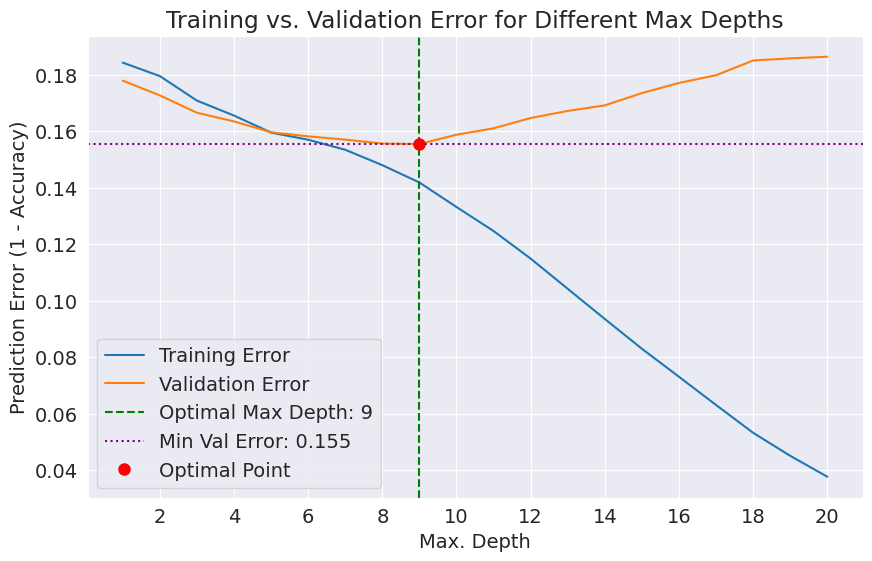

The optimal value for max_depth is 9, which results in a minimum validation error of 0.155.


In [75]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_acc = 1 - model.score(X_train, train_targets)
    val_acc = 1 - model.score(X_val, val_targets)
    return {'Max Depth': md, 'Training Error': train_acc, 'Validation Error': val_acc}

errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

plt.figure(figsize=(10, 6))
plt.plot(errors_df['Max Depth'], errors_df['Training Error'], label='Training Error')
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'], label='Validation Error')
plt.title('Training vs. Validation Error for Different Max Depths')
plt.xticks(range(0, 21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')

# Find the optimal max_depth (where Validation Error is minimum)
optimal_md_idx = errors_df['Validation Error'].idxmin()
optimal_md = errors_df.loc[optimal_md_idx, 'Max Depth']
min_val_error = errors_df.loc[optimal_md_idx, 'Validation Error']

# Plot a vertical dashed line at the optimal max_depth
plt.axvline(x=optimal_md, color='green', linestyle='--', label=f'Optimal Max Depth: {optimal_md}')

# Plot a horizontal dashed line at the minimum validation error
plt.axhline(y=min_val_error, color='purple', linestyle=':', label=f'Min Val Error: {min_val_error:.3f}')

# Plot a point at the intersection
plt.plot(optimal_md, min_val_error, 'o', color='red', markersize=8, label='Optimal Point')

plt.legend()
plt.grid(True)
plt.show()

print(f"The optimal value for max_depth is {int(optimal_md)}, which results in a minimum validation error of {min_val_error:.3f}.")

## Training a Random Forest

While tuning the hyperparameters of a single decision tree may lead to some improvements, a much more effective strategy is to combine the results of several decision trees trained with slightly different parameters. This is called a random forest.

The key idea here is that each decision tree in the forest will make different kinds of errors, and upon averaging, many of their errors will cancel out. This idea is also known as the "wisdom of the crowd" in common parlance:

<img src="https://i.imgur.com/4Dg0XK4.png" width="480">

A random forest works by averaging/combining the results of several decision trees:

<img src="https://1.bp.blogspot.com/-Ax59WK4DE8w/YK6o9bt_9jI/AAAAAAAAEQA/9KbBf9cdL6kOFkJnU39aUn4m8ydThPenwCLcBGAsYHQ/s0/Random%2BForest%2B03.gif" width="640">


We'll use the `RandomForestClassifier` class from `sklearn.ensemble`.

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
# Initialize a RandomForestClassifier model.
# n_jobs=-1 means that the model will use all available CPU cores for parallel processing,
# which can significantly speed up the training process for large datasets.
# random_state=42 is used to set the seed for the random number generator.
# This ensures that the results are reproducible, meaning you'll get the same output
# every time you run the code with this specific seed.
model = RandomForestClassifier(n_jobs=-1, random_state=42)

In [78]:
%%time
model.fit(X_train, train_targets)

CPU times: user 42.2 s, sys: 301 ms, total: 42.5 s
Wall time: 42.6 s


RandomForestClassifier(n_jobs=-1, random_state=42)

In [79]:
model.score(X_train, train_targets)

0.9999595910615429

In [80]:
model.score(X_val, val_targets)

0.8544483779235099

Once again, the training accuracy is 100%, but this time the validation accuracy is much better. In fact, it is better than the best single decision tree we had trained so far. Do you see the power of random forests?

This general technique of combining the results of many models is called "ensembling", it works because most errors of individual models cancel out on averaging. Here's what it looks like visually:

<img src="https://i.imgur.com/qJo8D8b.png" width="480">


We can also look at the probabilities for the predictions. The probability of a class is simply the fraction of trees which that predicted the given class.

In [81]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.94, 0.06],
       [0.98, 0.02],
       [0.97, 0.03],
       ...,
       [0.99, 0.01],
       [0.99, 0.01],
       [0.89, 0.11]])

In [82]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [83]:
print(len(model.estimators_))

100


In [84]:
# We can can access individual decision trees using `model.estimators_`
model.estimators_[0]

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)

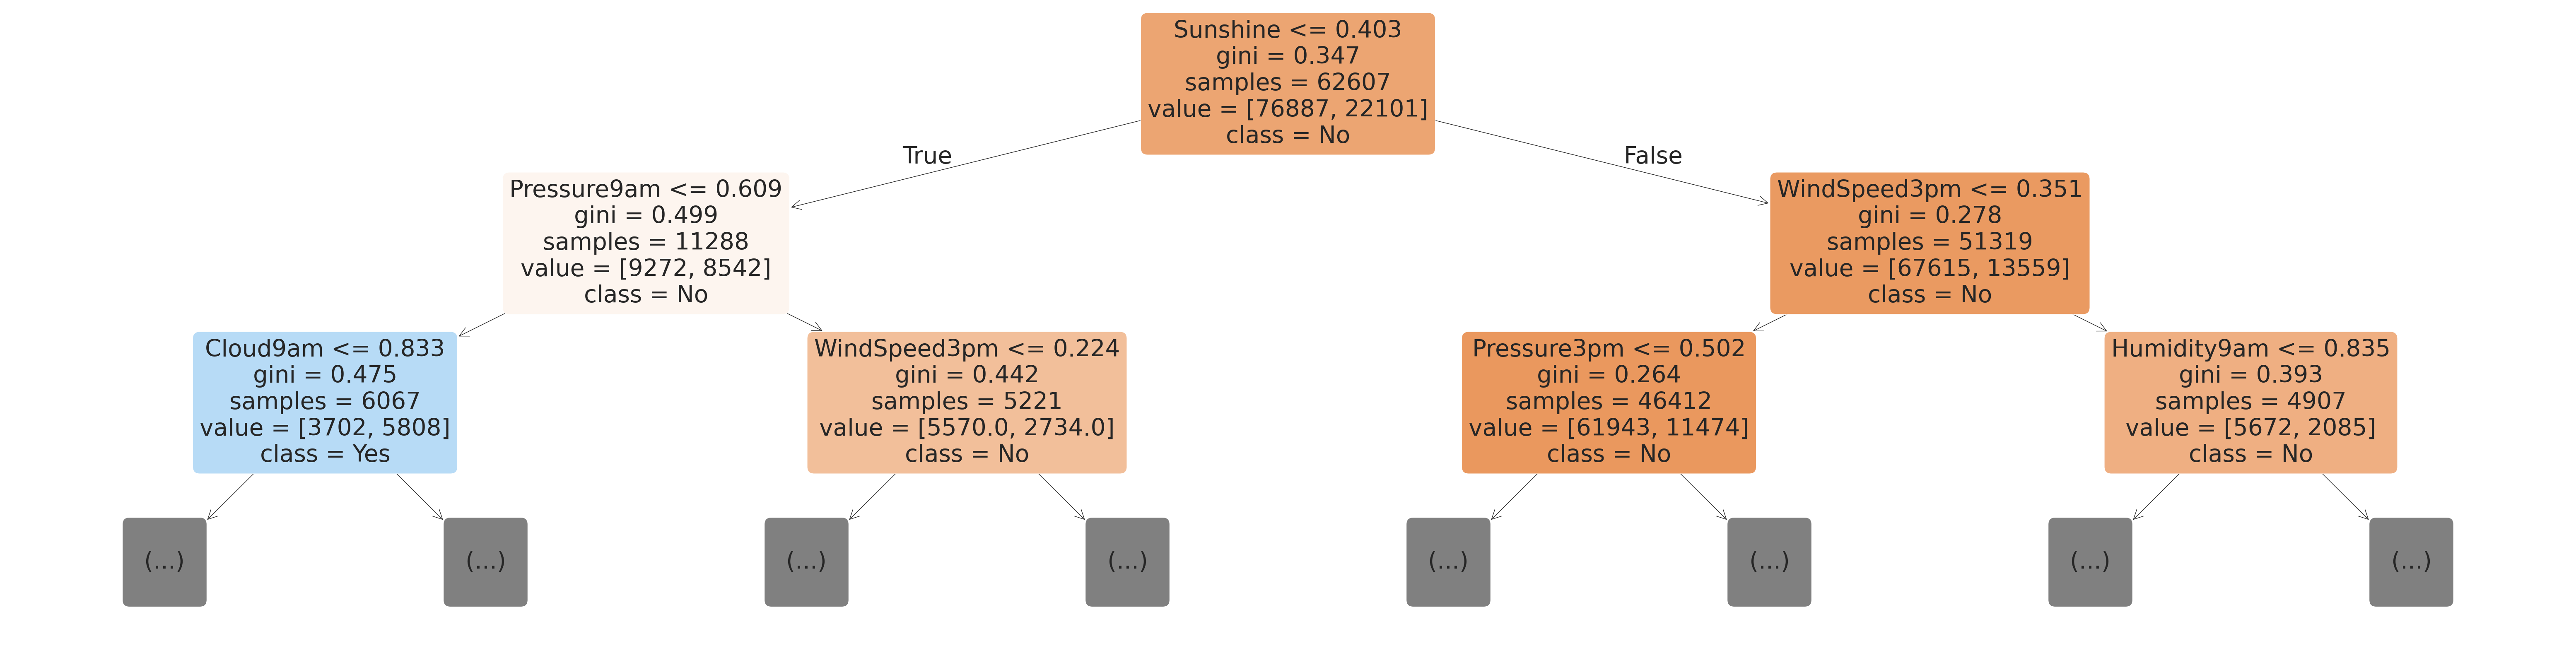

In [85]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[0], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

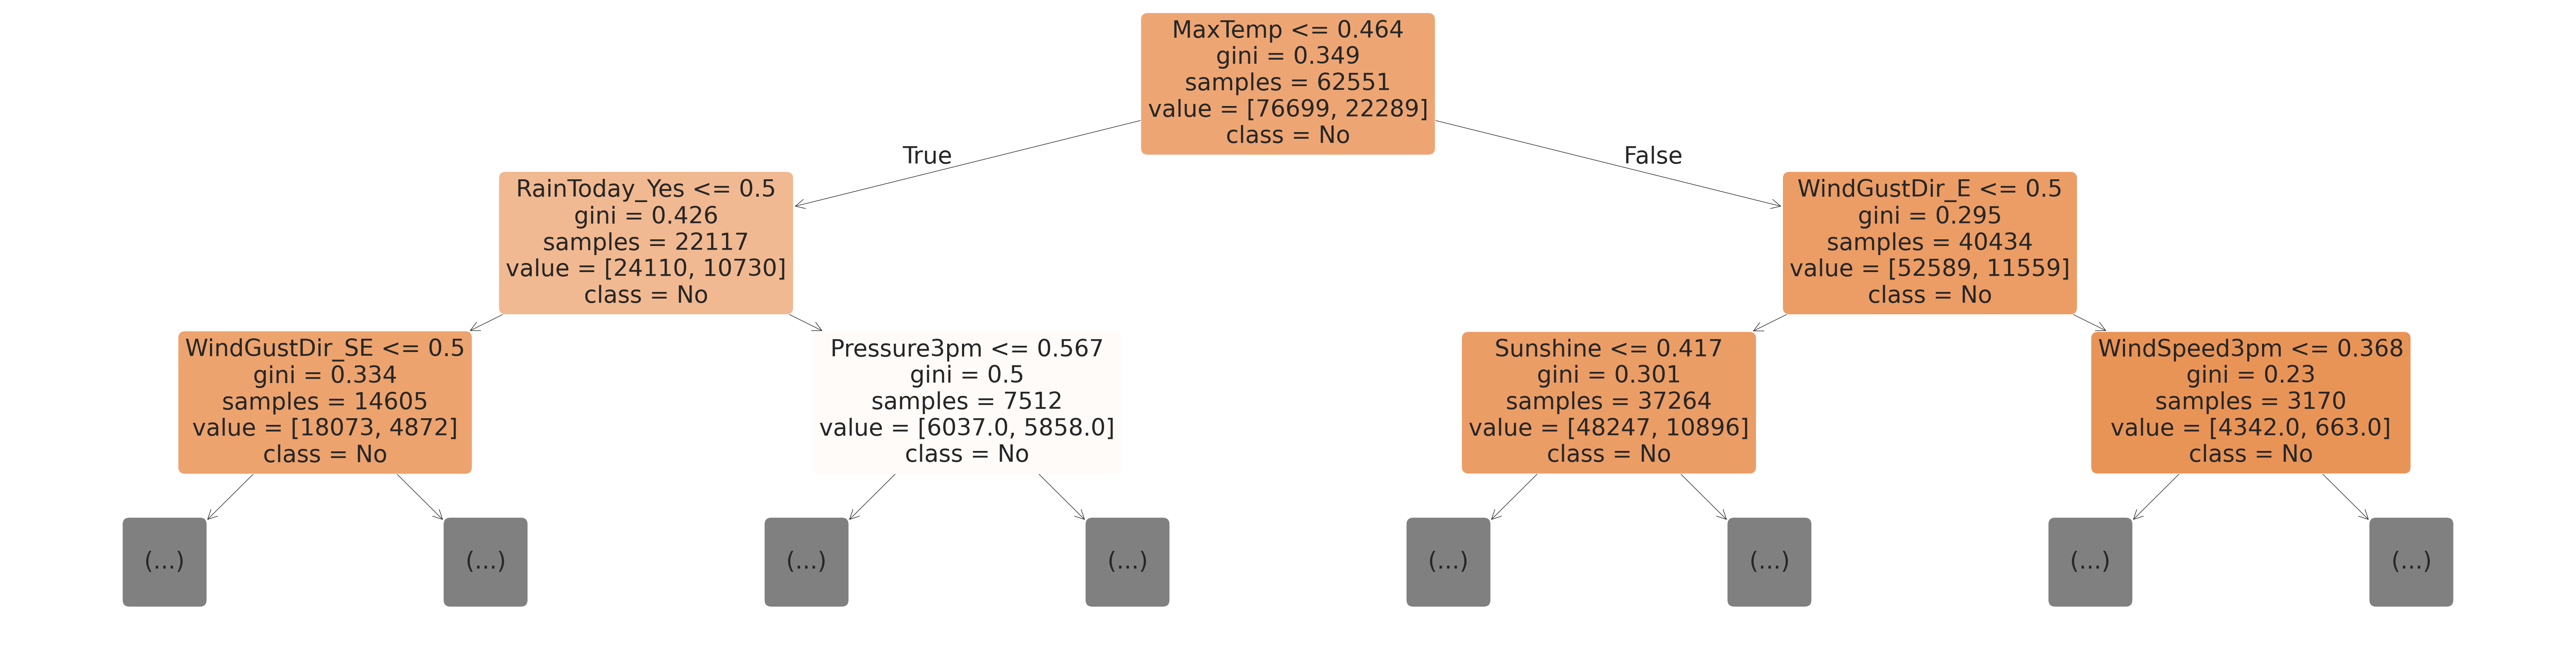

In [86]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[99], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

Just like decision tree, random forests also assign an "importance" to each feature, by combining the importance values from individual trees.

In [87]:
import pandas as pd

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    # 'feature_importances_' attributes in scikit-learn's tree-based models (like RandomForestClassifier)
    # represent the average importance of each feature across all decision trees in the forest.
    # The importance is calculated based on the Gini impurity reduction (or entropy reduction)
    # achieved by splits that involve the feature. A higher value means the feature is more
    # influential in making predictions.
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [88]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.140371
4,Sunshine,0.054490
11,Pressure3pm,0.054066
10,Pressure9am,0.048730
8,Humidity9am,0.048687
5,WindGustSpeed,0.045724
15,Temp3pm,0.045641
2,Rainfall,0.043722
1,MaxTemp,0.041509
0,MinTemp,0.041463


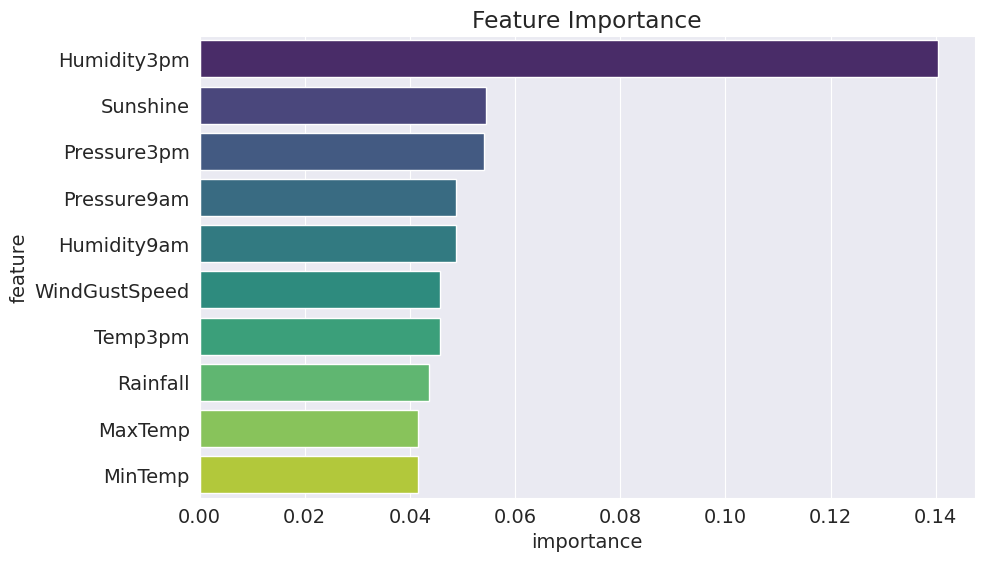

In [89]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature', hue='feature', palette='viridis');

## Hyperparameter Tuning with Random Forests

Just like decision trees, random forests also have several hyperparameters. In fact many of these hyperparameters are applied to the underlying decision trees.


In [90]:
base_model = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, train_targets)

In [91]:
base_train_acc = base_model.score(X_train, train_targets)
base_val_acc = base_model.score(X_val, val_targets)

In [92]:
base_accs = base_train_acc, base_val_acc
base_accs

(0.9999595910615429, 0.8544483779235099)

### `n_estimators`

This controls the number of decision trees in the random forest. The default value is 100. For larger datasets, it helps to have a greater number of estimators. As a general rule, try to have as few estimators as needed.


**10 estimators**

In [93]:
# Initialize a RandomForestClassifier model with specific hyperparameters.
# random_state=42: This parameter ensures reproducibility.
# It sets the seed for the random number generator, meaning that if you run the code multiple times,
# you'll get the same random splits and tree constructions within the forest.
# n_jobs=-1: This instructs the model to use all available CPU cores for parallel processing.
# This can significantly speed up the training of the random forest, as individual trees can be built independently.
# n_estimators=10: This sets the number of decision trees in the forest to 10.
# While a higher number generally leads to a more robust model, it also increases training time.
# This value is likely chosen for a quick initial test or specific performance requirements.
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=10)

In [94]:
model.fit(X_train, train_targets)

RandomForestClassifier(n_estimators=10, n_jobs=-1, random_state=42)

In [95]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.9870893441629288, 0.8434797748244444)

In [96]:
base_accs

(0.9999595910615429, 0.8544483779235099)

In [97]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=500)
model.fit(X_train, train_targets)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [98]:
model.score(X_train, train_targets)

0.9999797955307714

In [99]:
model.score(X_val, val_targets)

0.8557831814752481

In [100]:
base_accs

(0.9999595910615429, 0.8544483779235099)

### `max_features`

Instead of picking all features for every split, we can specify only a fraction of features to be chosen randomly.

<img src="https://i.imgur.com/FXGWMDY.png" width="720">

Notice that the default value `auto` causes only $\sqrt{n}$ out of total features ( $n$ ) to be chosen randomly at each split. This is the reason each decision tree is in the forest is different. While it may seem counterintuitive, choosing all features for every split of every tree will lead to identical trees, so the random forest will not generalize well.

In [101]:
test_params(max_features='log2')

NameError: name 'test_params' is not defined

In [ ]:
test_params(max_features=3)

In [ ]:
test_params(max_features=6)

In [ ]:
base_accs

In [ ]:
max_features_options = ['sqrt', 'log2'] + list(range(1, X_train.shape[1] + 1, 10)) # Test 'sqrt', 'log2', and integers from 1 to all features in steps of 10

results = []
for mf in max_features_options:
    # test_params returns (train_accuracy, val_accuracy)
    train_acc, val_acc = test_params(max_features=mf)
    results.append({
        'Max Features': str(mf), # Convert to string for consistent plotting if mixing types
        'Training Accuracy': train_acc,
        'Validation Accuracy': val_acc
    })

results_df = pd.DataFrame(results)

# Find the optimal 'Max Features' based on the highest validation accuracy
optimal_mf_row = results_df.loc[results_df['Validation Accuracy'].idxmax()]
optimal_mf_value = optimal_mf_row['Max Features']
max_val_accuracy = optimal_mf_row['Validation Accuracy']

print(f"Results for different max_features:\n{results_df}")
print(f"\nOptimal Max Features: {optimal_mf_value} with Validation Accuracy: {max_val_accuracy:.4f}")

# Plotting the results
plt.figure(figsize=(14, 7))
plt.plot(results_df['Max Features'], results_df['Training Accuracy'], label='Training Accuracy', marker='o')
plt.plot(results_df['Max Features'], results_df['Validation Accuracy'], label='Validation Accuracy', marker='o')
plt.xticks(rotation=90)
plt.xlabel('Max Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Max Features')
plt.axvline(x=optimal_mf_value, color='green', linestyle='--', label=f'Optimal Max Features: {optimal_mf_value}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### `max_depth` and `max_leaf_nodes`

These arguments are passed directly to each decision tree, and control the maximum depth and max. no leaf nodes of each tree respectively. By default, no maximum depth is specified, which is why each tree has a training accuracy of 100%. You can specify a `max_depth` to reduce overfitting.

<img src="https://i.imgur.com/EJCrSZw.png" width="480">

Let's define a helper function to `max depth`, `max_leaf_nodes` and other hyperparameters easily.

In [ ]:
def test_params(**params):
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params).fit(X_train, train_targets)
    return model.score(X_train, train_targets), model.score(X_val, val_targets)

In [ ]:
test_params(max_depth=5)

In [ ]:
test_params(max_depth=25)

In [ ]:
test_params(max_leaf_nodes=2**5)

In [ ]:
test_params(max_leaf_nodes=2**20)

In [ ]:
base_accs # no max depth or max leaf nodes

The optimal values of `max_depth` and `max_leaf_nodes` lies somewhere between 0 and unbounded.

### `min_samples_split` and `min_samples_leaf`

By default, the decision tree classifier tries to split every node that has 2 or more. You can increase the values of these arguments to change this behavior and reduce overfitting, especially for very large datasets.

In [ ]:
test_params(min_samples_split=3, min_samples_leaf=2)